In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))

from src.ring_attractor import RingAttractor, SpikeProcessor
from src.ring_attractor.plotting import polar_snapshot

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

In [5]:
N = 100               # Number of neurons
J0 = -2.0             # Global inhibition
J1 = 4.0              # Local excitation
STEEPNESS = 4.0       # f-I curve steepness
ALPHA = 0.01          # Leak rate (= dt / tau)
SIGMA = 0.0           # Noise off for clean demos
GAMMA = 2.0           # Divisive normalisation strength

T_CUE = 2000          # Steps with external cue
T_FREE = 5500         # Steps of autonomous dynamics
T_TOTAL = T_CUE + T_FREE

CUE_AMPLITUDE = 3.0   # Peak of the Gaussian cue
THETA_TARGET = np.pi / 3  # 60°

SEED = 42

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

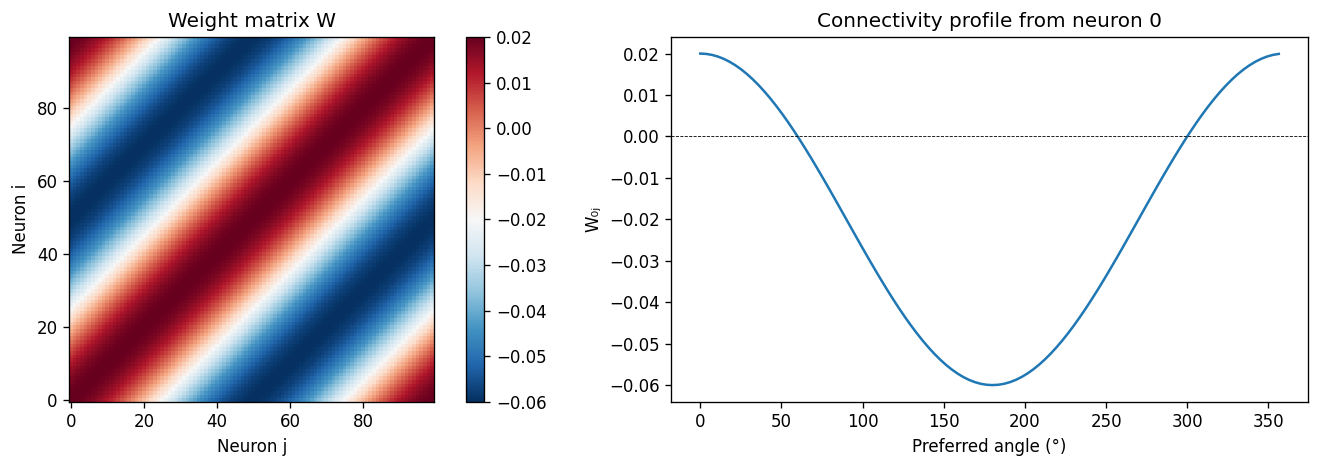

In [6]:
# ## 1. Create the network and inspect initial state
#
# The ring attractor is a network of 100 neurons arranged on a circle.
# Each neuron has a preferred angle θ_i = 2πi/N.  Connectivity follows
# a cosine kernel: W_ij = (J0 + J1 cos(θ_i − θ_j)) / N.

ring = RingAttractor(N=N, J0=J0, J1=J1, steepness=STEEPNESS, alpha=ALPHA, sigma=SIGMA)

# Show the weight matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
im = ax1.imshow(ring.weights, cmap="RdBu_r", origin="lower")
ax1.set_xlabel("Neuron j")
ax1.set_ylabel("Neuron i")
ax1.set_title("Weight matrix W")
plt.colorbar(im, ax=ax1)

# Weights from neuron 0 to all others (the connectivity profile)
ax2.plot(np.degrees(ring.angles), ring.weights[0], color="tab:blue")
ax2.set_xlabel("Preferred angle (°)")
ax2.set_ylabel("W₀ⱼ")
ax2.set_title("Connectivity profile from neuron 0")
ax2.axhline(0, color="k", lw=0.5, ls="--")
plt.tight_layout()
plt.show()

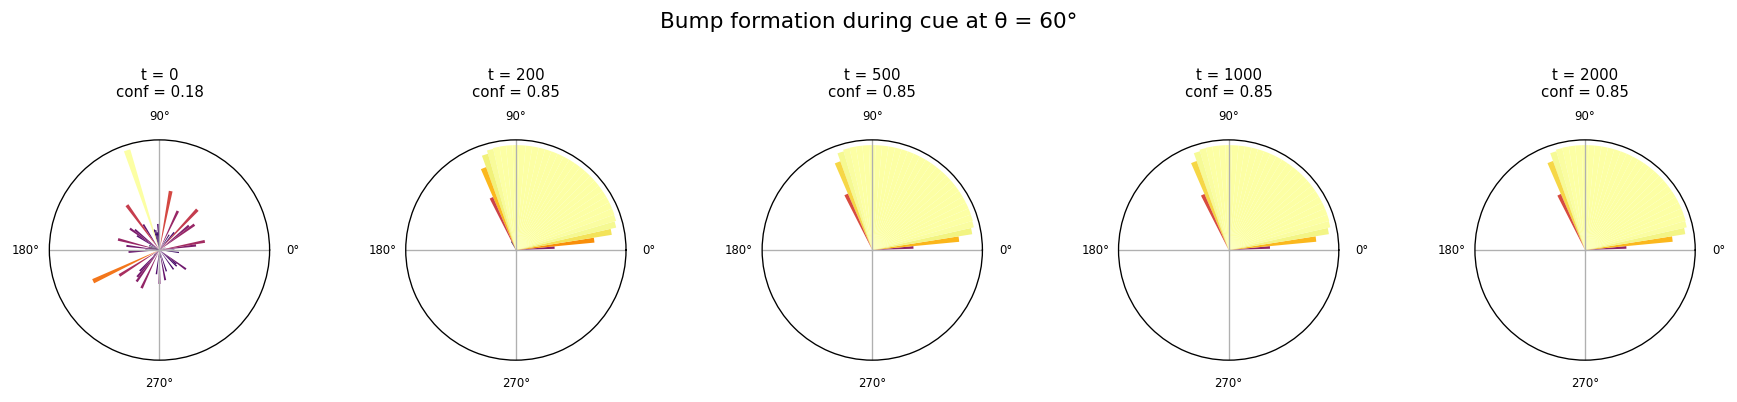

In [8]:
# ## 2. Apply a cue and form a bump
#
# We inject a localised Gaussian cue at θ = 60° for a few hundred steps
# and watch the bump form.

snap_steps = [0, 200, 500, 1000, 2000]
res_cue = ring.simulate(T=max(snap_steps) + 1, cue_angles=[THETA_TARGET], cue_duration=max(snap_steps) + 1, seed=SEED)

fig, axes = plt.subplots(1, len(snap_steps), figsize=(15, 3), subplot_kw={"projection": "polar"})
fig.suptitle(f"Bump formation during cue at θ = {np.degrees(THETA_TARGET):.0f}°", fontsize=13, y=1.05)
for ax, t in zip(axes, snap_steps):
    polar_snapshot(ax, res_cue.rates[t], res_cue.angles, title=f"t = {t}\nconf = {res_cue.confidence[t]:.2f}")

plt.tight_layout()
plt.show()

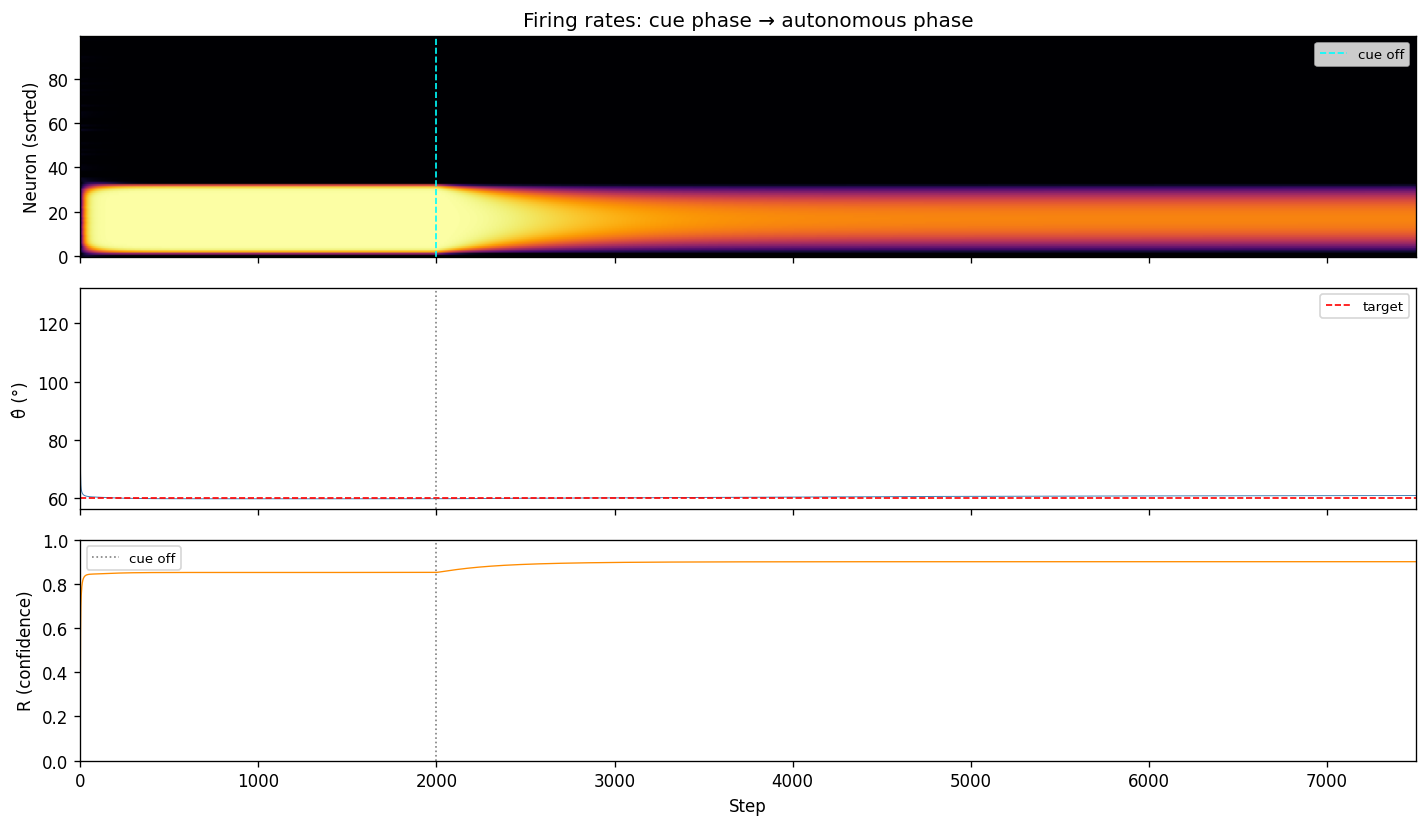

In [9]:
# ## 3. Cue → autonomous: the bump persists
#
# After the cue is removed (t = 2000), the network runs purely on its
# recurrent dynamics.  The bump should stay locked at 60°.

res = ring.simulate(T=T_TOTAL, cue_angles=[THETA_TARGET],
                    cue_duration=T_CUE, seed=SEED)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

# Heatmap
order = np.argsort(res.angles)
ax1.imshow(res.rates[:, order].T, aspect="auto", origin="lower", cmap="inferno")
ax1.axvline(T_CUE, color="cyan", ls="--", lw=1, label="cue off")
ax1.set_ylabel("Neuron (sorted)"); ax1.legend(fontsize=8)
ax1.set_title("Firing rates: cue phase → autonomous phase")

# Decoded angle
ax2.plot(np.degrees(res.theta), lw=0.6, color="steelblue")
ax2.axhline(np.degrees(THETA_TARGET), color="red", ls="--", lw=1, label="target")
ax2.axvline(T_CUE, color="gray", ls=":", lw=1)
ax2.set_ylabel("θ̂ (°)"); ax2.legend(fontsize=8)

# Confidence
ax3.plot(res.confidence, lw=0.8, color="darkorange")
ax3.axvline(T_CUE, color="gray", ls=":", lw=1, label="cue off")
ax3.set_ylabel("R (confidence)"); ax3.set_xlabel("Step")
ax3.set_ylim(0, 1); ax3.legend(fontsize=8)

plt.tight_layout(); plt.show()

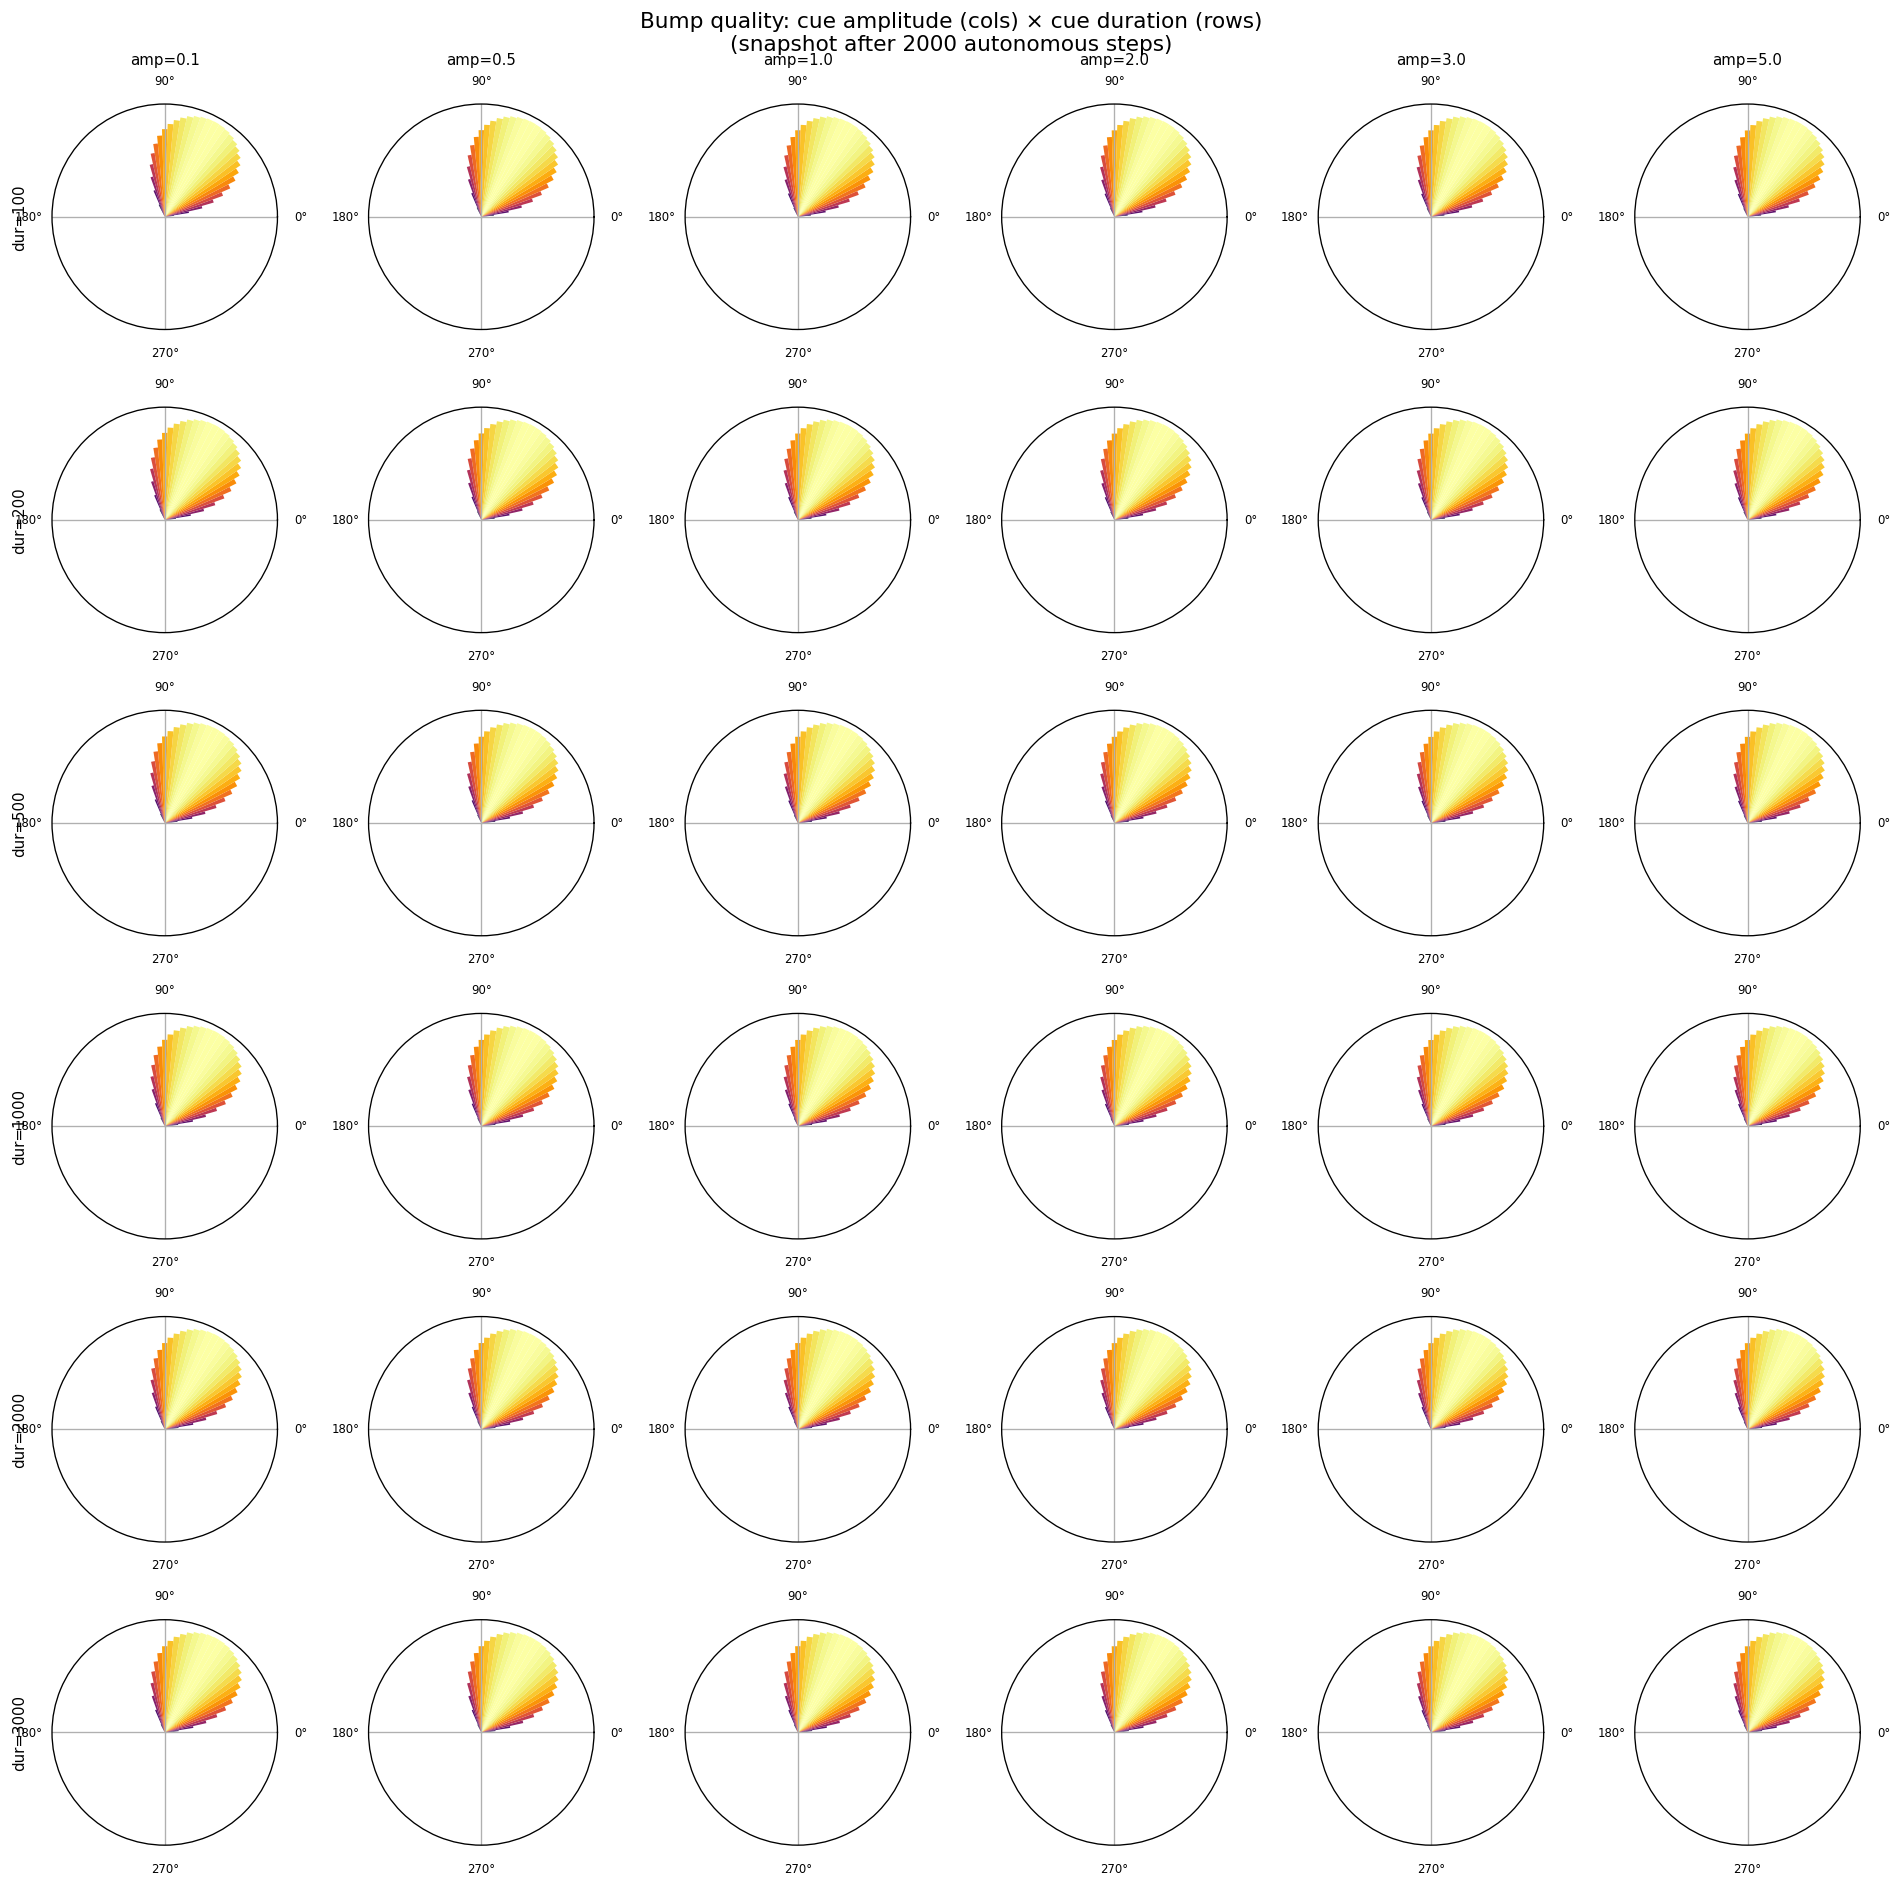

In [10]:
# ## 4. Parameter sweep: cue amplitude × cue duration
#
# How strong / long must the cue be to establish a stable bump?

amplitudes = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0]
durations = [100, 200, 500, 1000, 2000, 3000]

fig, axes = plt.subplots(len(durations), len(amplitudes), figsize=(16, 16),
                         subplot_kw={"projection": "polar"})

for row, dur in enumerate(durations):
    for col, amp in enumerate(amplitudes):
        r = ring.simulate(T=dur + 2000, cue_angles=[THETA_TARGET],
                          cue_duration=dur, cue_amplitude=amp, seed=SEED)
        # Snapshot at end of trial (after 2000 free steps)
        ax = axes[row, col]
        polar_snapshot(ax, r.rates[-1], r.angles)
        if row == 0:
            ax.set_title(f"amp={amp}", fontsize=9)
        if col == 0:
            ax.set_ylabel(f"dur={dur}", fontsize=9, labelpad=15)

fig.suptitle("Bump quality: cue amplitude (cols) × cue duration (rows)\n"
             "(snapshot after 2000 autonomous steps)", fontsize=13)
plt.tight_layout(); plt.show()

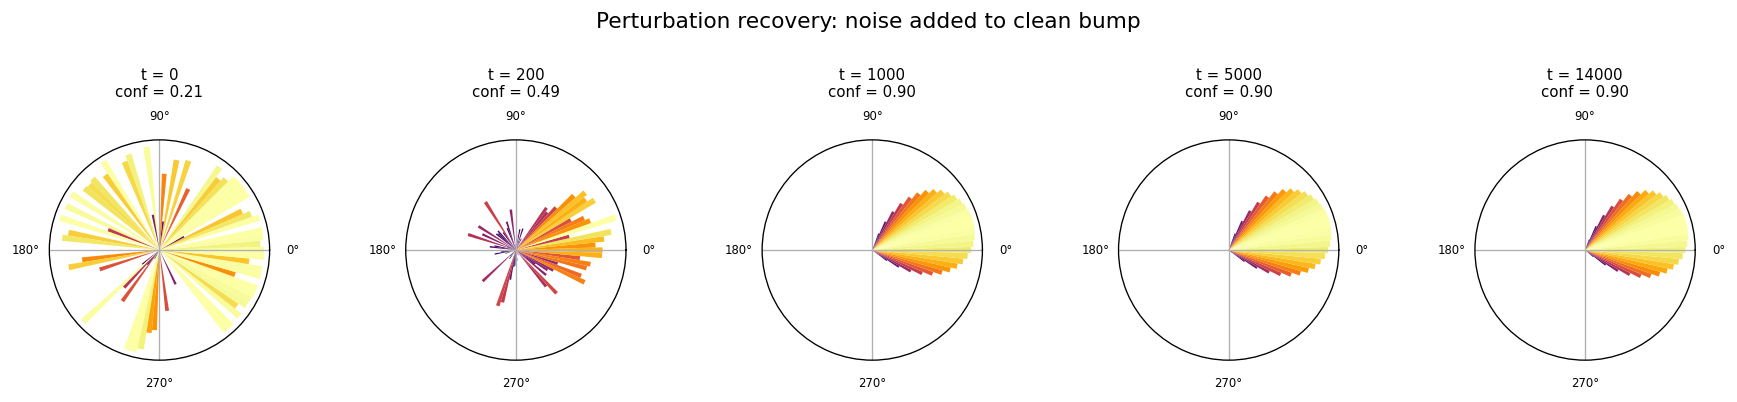

In [11]:
# ## 5. Perturbation recovery
#
# A true attractor cleans up noise.  We form a bump, add a large
# perturbation, and watch the dynamics restore a clean bump.

res_clean = ring.simulate(T=5000, cue_angles=[0.0], cue_duration=T_CUE, seed=10)
clean_rates = res_clean.rates[-1]

rng = np.random.default_rng(99)
perturbed = clean_rates + 0.5 * rng.standard_normal(N)

res_pert = ring.simulate(T=15000, cue_angles=None, seed=20, init_rates=perturbed)

snap_times = [0, 200, 1000, 5000, 14000]
fig, axes = plt.subplots(1, len(snap_times), figsize=(15, 3),
                         subplot_kw={"projection": "polar"})
fig.suptitle("Perturbation recovery: noise added to clean bump", fontsize=13, y=1.05)
for ax, t in zip(axes, snap_times):
    polar_snapshot(ax, res_pert.rates[t], res_pert.angles,
                   title=f"t = {t}\nconf = {res_pert.confidence[t]:.2f}")
plt.tight_layout(); plt.show()

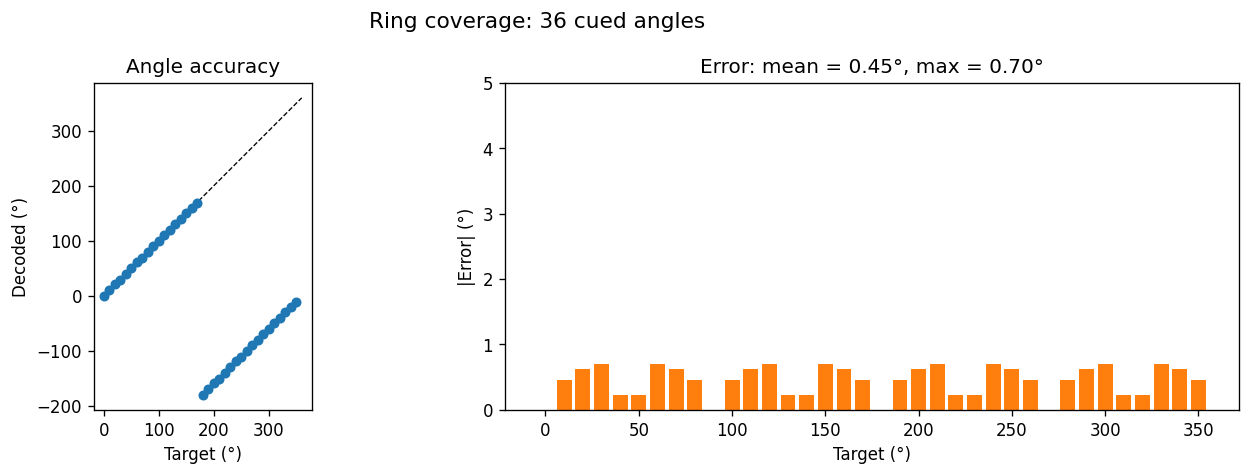

Mean confidence: 0.900  |  Mean |error|: 0.45°


In [12]:
# ## 6. Multi-angle coverage
#
# The attractor should support bumps at any angle, not just a few
# discrete ones.  We cue 36 evenly-spaced angles and check.

N_ANGLES = 36
targets = np.linspace(0, 2 * np.pi, N_ANGLES, endpoint=False)
decoded = np.zeros(N_ANGLES)
confs = np.zeros(N_ANGLES)

for i, tgt in enumerate(targets):
    r = ring.simulate(T=T_TOTAL, cue_angles=[tgt], cue_duration=T_CUE, seed=i * 7)
    z = np.exp(1j * r.theta[T_CUE + 1000:]).mean()  # average over late autonomous phase
    decoded[i] = np.angle(z)
    confs[i] = r.confidence[T_CUE + 1000:].mean()

errors = np.abs(np.degrees(np.arctan2(np.sin(decoded - targets),
                                       np.cos(decoded - targets))))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Ring coverage: {N_ANGLES} cued angles", fontsize=13)

ax1.scatter(np.degrees(targets), np.degrees(decoded), s=25, c="tab:blue", zorder=3)
ax1.plot([0, 360], [0, 360], "k--", lw=0.8)
ax1.set_xlabel("Target (°)"); ax1.set_ylabel("Decoded (°)")
ax1.set_title("Angle accuracy"); ax1.set_aspect("equal")

ax2.bar(np.degrees(targets), errors, width=8, color="tab:orange")
ax2.set_xlabel("Target (°)"); ax2.set_ylabel("|Error| (°)")
ax2.set_title(f"Error: mean = {errors.mean():.2f}°, max = {errors.max():.2f}°")
ax2.set_ylim(0, 5)

plt.tight_layout(); plt.show()
print(f"Mean confidence: {confs.mean():.3f}  |  Mean |error|: {errors.mean():.2f}°")

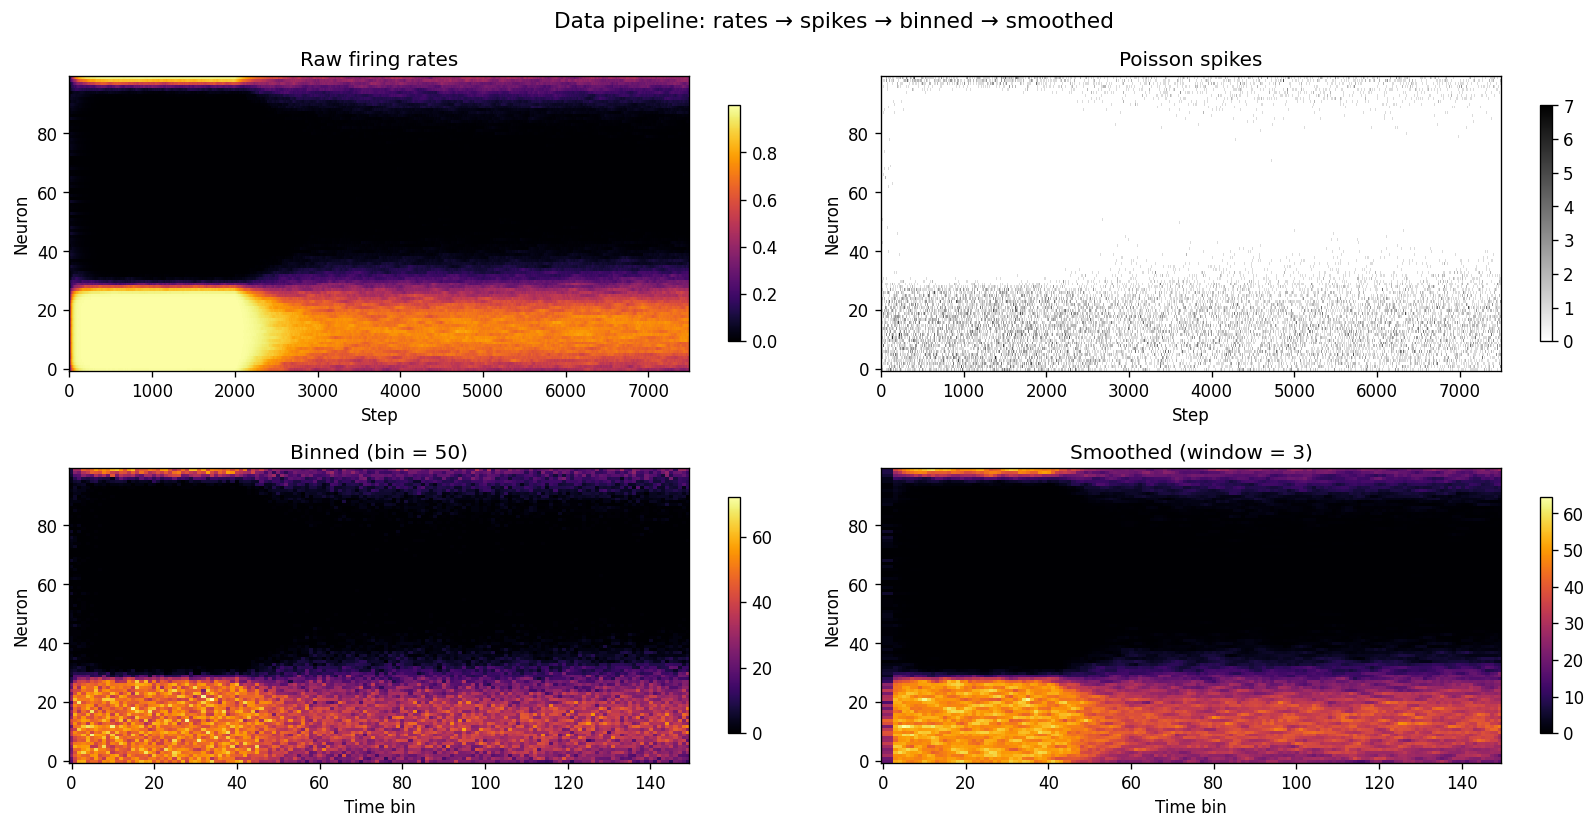

In [13]:
# ## 7. Spike generation pipeline
#
# For training data we convert continuous rates to Poisson spikes,
# temporally bin, and smooth.

ring_noisy = RingAttractor(N=N, J0=J0, J1=J1, steepness=STEEPNESS,
                           alpha=ALPHA, sigma=0.1, gamma=GAMMA)  # noise on for realistic spikes
res_sp = ring_noisy.simulate(T=T_TOTAL, cue_angles=[np.pi / 4],
                             cue_duration=T_CUE, seed=SEED)

sp = SpikeProcessor(dt=0.01, rate_scale=100, bin_factor=50, smoothing_window=3)
data = sp.process(res_sp.rates, seed=SEED)

order = np.argsort(res_sp.angles)
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle("Data pipeline: rates → spikes → binned → smoothed", fontsize=13)

panels = [
    (res_sp.rates[:, order].T, "Raw firing rates", "inferno"),
    (data.spikes[:, order].T, "Poisson spikes", "gray_r"),
    (data.binned[:, order].T, f"Binned (bin = {sp.bin_factor})", "inferno"),
    (data.smoothed[:, order].T, f"Smoothed (window = {sp.smoothing_window})", "inferno"),
]
for ax, (d, title, cmap) in zip(axes.flat, panels):
    im = ax.imshow(d, aspect="auto", origin="lower", cmap=cmap, interpolation="nearest")
    ax.set_title(title); ax.set_ylabel("Neuron")
    ax.set_xlabel("Time bin" if d.shape[1] < 1000 else "Step")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout(); plt.show()